In [ ]:
import os, sys, argparse, math, logging, csv, gc, random
from rdkit import Chem
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from tqdm import tqdm
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import Descriptors, Lipinski

# Figure 3 c and supplementary figure 2 c (Figure 3.4.3 c and A.4.2 c)

## Tanimoto reconstruction of evaluation molecules

In [ ]:
smiles_list = pd.read_csv('../../data/hvae_training/evaluation_molecules.csv').smiles.tolist()
decoded_smiles = pd.read_csv('../../data/hvae_training/decoded_evaluation_molecules.csv').decoded_smiles.tolist()

In [3]:
len(decoded_smiles), len(smiles_list)

(19462, 19462)

In [4]:
######### EVALUATE TANIMOTO TO ORIGINAL MOLECULES #########
# Computing Morgan Fingerprints for both input and decoded SMILES
def smiles_to_morgan(smiles_list, radius=2):
    fps = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius) if mol else None
        except:
            fp = None
        fps.append(fp)
    return fps

input_mfps = smiles_to_morgan(smiles_list)
decoded_mfps = smiles_to_morgan(decoded_smiles)

# Computing Tanimoto Similarity per pair of molecules
tanimotos = []
for i in range(len(input_mfps)):
    try:
        ts = TanimotoSimilarity(input_mfps[i], decoded_mfps[i])
    except:
        ts = 0
    tanimotos.append(ts)

data = tanimotos
kde = gaussian_kde(data)
x_min = np.min(data)
x_max = np.max(data)
x_grid = np.linspace(x_min, x_max, 200)
density = kde(x_grid)

# Convert density to % of molecules
# 1. Get bin width from x_grid
bin_width = x_grid[1] - x_grid[0]
# 2. Scale so the total area equals 100 (%)
density_percent = density * 100 * bin_width

# Calculate the width of one step in your x_grid
step_size = x_grid[1] - x_grid[0]

# Transform density to actual percentage per step
# (Density * Step Size = Probability) * 100 = Percentage
plot_y = density_percent * step_size * 100


[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerator
[10:00:07] DEPRECATION WARNING: please use MorganGenerat

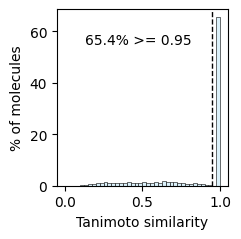

In [6]:
data = np.array(tanimotos, dtype=float)

percent_above_095 = 100 * np.mean(data >= 0.95)

bins = np.arange(0, 1.01, 0.025)
weights = np.ones_like(data) * 100 / len(data)

plt.figure(figsize=(2.5, 2.5))

plt.hist(
    data,
    bins=bins,
    weights=weights,
    color='#dbf1faff',
    alpha=1,
    edgecolor='black',
    linewidth=0.4,
)

plt.axvline(x=0.95, color='black', linestyle='--', linewidth=1)

plt.text(
    0.82,
    plt.ylim()[1] * 0.8,
    f'{percent_above_095:.1f}% >= 0.95',
    color='black',
    ha='right'
)

plt.ylabel('% of molecules')
plt.xlabel('Tanimoto similarity')
plt.tight_layout()


In [7]:
######### EVALUATE % OF IDENTICAL OR SIMILAR MOLECULES #########
matches = sum(1 for a, b in zip(decoded_smiles, smiles_list) if a == b)
print(f"Exact SMILES reconstruction matches: {matches}/{len(smiles_list)} ({np.round(matches / len(smiles_list) * 100, 2)}%)")
print(f"% reconstruction with Tanimoto of 1 (>0.98): {np.round(sum(1 for ts in tanimotos if ts >=0.98) / len(tanimotos) * 100, 2)}%")
print(f'Mean Tanimoto: {np.round(np.mean(tanimotos), 2)}')
print(f'Median Tanimoto: {np.round(np.median(tanimotos), 2)}')
tanimotos = np.array(tanimotos)
print(f'% molecules >0.9 Tanimoto: {np.round(sum(tanimotos>0.9)*100/len(tanimotos), 2)}')
print(f'% molecules >0.8 Tanimoto: {np.round(sum(tanimotos>0.8)*100/len(tanimotos), 2)}')
print(f'% molecules >0.7 Tanimoto: {np.round(sum(tanimotos>0.7)*100/len(tanimotos), 2)}')

Exact SMILES reconstruction matches: 9843/19462 (50.58%)
% reconstruction with Tanimoto of 1 (>0.98): 65.32%
Mean Tanimoto: 0.83
Median Tanimoto: 1.0
% molecules >0.9 Tanimoto: 65.79
% molecules >0.8 Tanimoto: 68.78
% molecules >0.7 Tanimoto: 73.27


In [8]:
len(tanimotos)

19462

In [9]:
sum(tanimotos>=0.95)

np.int64(12728)

In [10]:
12728/19462

0.6539923954372624

/tmp/ipykernel_6145/1696883178.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=mw_bins_sorted, patch_artist=True,


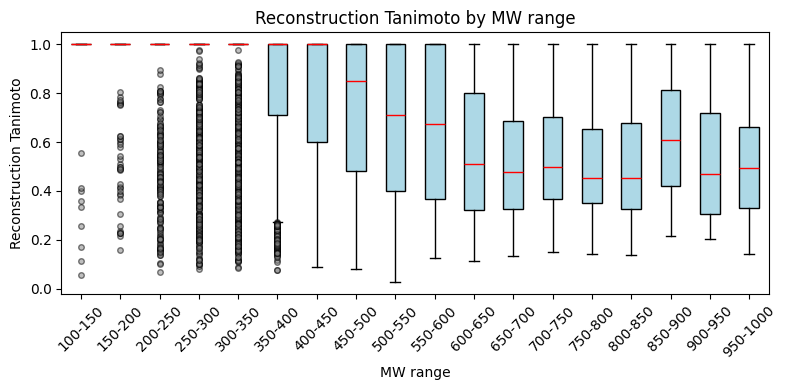

In [11]:
######### PLOT PERFORMANCE PER MW RANGE #########

mw = [Descriptors.MolWt(Chem.MolFromSmiles(smi)) for smi in smiles_list if smi is not None]

# Define MW bins every 50 Da
bin_size = 50
min_mw = np.min(mw) // bin_size * bin_size
max_mw = (np.max(mw) // bin_size + 1) * bin_size
bins = np.arange(min_mw, max_mw + bin_size, bin_size)

# Create bin labels (optional: "start-end")
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# Bin the MW values
df = pd.DataFrame({'MW': mw, 'Tanimoto': tanimotos})
df['MW_bin'] = pd.cut(df['MW'], bins=bins, labels=labels, include_lowest=True)

# Plot boxplot
# Group the data by MW_bin
mw_bins_sorted = sorted(df['MW_bin'].unique())
groups = [df[df['MW_bin'] == g]['Tanimoto'].values for g in mw_bins_sorted]

# Plot boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(groups, labels=mw_bins_sorted, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(markerfacecolor='gray', marker='o', markersize=4, alpha=0.5))

plt.xticks(rotation=45)
plt.xlabel("MW range")
plt.ylabel("Reconstruction Tanimoto")
plt.title("Reconstruction Tanimoto by MW range")
plt.tight_layout()
# plt.savefig('/aloy/home/grojas/tesis/antibiotics/final_pipeline/paper/fig3/tanimoto_reconstruction_per_mw_range.png')

## hVAE Vocab

In [ ]:
# Plot motif size
with open('../../data/hvae_training/vocab.txt', 'r') as file:
    vocab_ = sorted({tuple(line.split('\t')) for line in file.read().splitlines()})

motifs, scaffolds = zip(*vocab_)

motif_sizes = [len(Chem.MolFromSmiles(x).GetAtoms()) for x in motifs]

In [ ]:
with open('../../data/figures_source_data/original_hvae_vocab_saldivar_espinoza.txt', 'r') as file:
    bryan_vocab = sorted({tuple(line.split(' ')) for line in file.read().splitlines()})

In [ ]:
b_motifs, b_scaffolds = zip(*bryan_vocab)

In [ ]:
len(b_motifs), len(motifs)

(3229, 2834)

In [ ]:
motif_sizes_bryan = [len(Chem.MolFromSmiles(x).GetAtoms()) for x in b_motifs]

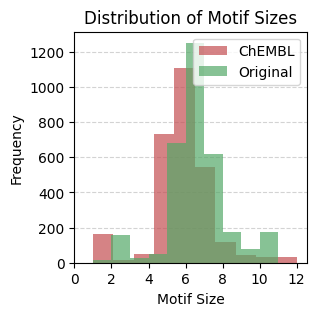

In [ ]:
chembl_color = "#C44E52"
original_color = "#55A868"

plt.figure(figsize=(3, 3))
plt.hist(motif_sizes, bins=10, zorder=2, alpha=0.7, label='ChEMBL', color=chembl_color)
plt.hist(motif_sizes_bryan, bins=10, zorder=2, alpha=0.7, label="Original", color=original_color)

plt.xticks(range(0, max(max(motif_sizes), max(motif_sizes_bryan)) + 1,2))
plt.title('Distribution of Motif Sizes')
plt.xlabel('Motif Size')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', color='lightgrey', ls='--', zorder=0)
plt.show()

In [ ]:
max(motif_sizes), max(motif_sizes_bryan)

(12, 11)

In [ ]:
len(set(b_motifs).intersection(set(motifs)))

687

In [ ]:
len(set(motifs))

809

In [ ]:
len(set(b_motifs))

921

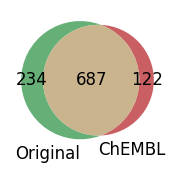

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Create Venn diagram

intersection_color = "#8D7B5D"

plt.figure(figsize=(2,2))  # smaller than default 6x6
venn = venn2([set(b_motifs), set(motifs)], set_labels=("Original", "ChEMBL"),set_colors=(original_color, chembl_color),alpha=0.9)

for label in venn.subset_labels:
    if label is not None:
        label.set_fontsize(12)

plt.show()

# Figure 3 d and e (Figure 3.4.3 d and e)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# All these reports were generated using /src/figures/fig3_auxiliary_code.py

FIG3_DIR = Path("../../data/figures_source_data")

generation_summary = pd.read_csv(
    FIG3_DIR / "fig3_generation_decoding_uniqueness_summary.csv"
)

tanimoto_results = pd.read_csv(
    FIG3_DIR / "fig3_generated_closest_intraset_and_active_tanimoto_per_molecule.csv"
)

species_tanimoto_summary = pd.read_csv(
    FIG3_DIR / "fig3_generated_closest_tanimoto_species_summary.csv"
)

print(generation_summary.shape)
print(tanimoto_results.shape)
print(species_tanimoto_summary.shape)

display(generation_summary.head())
display(tanimoto_results.head())
display(species_tanimoto_summary.head())

(274, 10)
(247115, 13)
(274, 9)


,species,n_files,n_generated,n_decoded_raw,n_decoded_valid,n_standardization_failed,n_unique_valid,pct_decoded,pct_unique_among_decoded,pct_unique_among_generated
0,acinetobacterbaumannii,2,1000,1000,1000,0,1000,100.0,100.000000,100.000000
1,acinetobacterbaylyi,1,900,900,900,0,900,100.0,100.000000,100.000000
2,acinetobactercalcoaceticus,1,900,900,900,0,899,100.0,99.888889,99.888889
3,acinetobactercalcoaceticussubsp.anitratus,1,900,900,900,0,898,100.0,99.777778,99.777778
4,acinetobacterhaemolyticus,1,900,900,900,0,900,100.0,100.000000,100.000000


,decoded_smiles,species,source_dir,decoded_index,smiles_std,closest_intraset_tanimoto,closest_intraset_index,closest_intraset_smiles,closest_active_tanimoto,closest_active_index,closest_active_smiles,n_generated_valid_for_species,n_active_reference_for_species
0,Brc1ccc(-c2cncc(OCc3scc4ccccc34)n2)cc1,agrobacteriumtumefaciens,/aloy/home/grojas/tesis/antibiotics/final_pipe...,0,Brc1ccc(-c2cncc(OCc3scc4ccccc34)n2)cc1,0.456140,536,Brc1ccc(-c2cncc(OCc3ccc4ccccc4c3)n2)nc1,0.197183,72,Oc1cccc(C2=Nc3ccccc3SC(c3ccc(Br)cc3)C2)c1,900,84
1,Brc1ccc(-c2cc(CSc3n[nH]c4ccccc34)ccn2)cc1,agrobacteriumtumefaciens,/aloy/home/grojas/tesis/antibiotics/final_pipe...,1,Brc1ccc(-c2cc(CSc3[nH]nc4ccccc34)ccn2)cc1,0.571429,410,Brc1cccc(-c2ccnc(CSc3[nH]nc4ccccc34)c2)c1,0.175676,72,Oc1cccc(C2=Nc3ccccc3SC(c3ccc(Br)cc3)C2)c1,900,84
2,OCC1=CN(c2cccc(Br)c2)CC1,agrobacteriumtumefaciens,/aloy/home/grojas/tesis/antibiotics/final_pipe...,2,OCC1=CN(c2cccc(Br)c2)CC1,0.418182,64,Clc1cccc(N2C=C(CCOc3cccc(Br)n3)CC2)c1,0.171875,72,Oc1cccc(C2=Nc3ccccc3SC(c3ccc(Br)cc3)C2)c1,900,84
3,ClCc1ccc2nc(-c3cccc4ccc(Cl)nc34)[nH]c2c1,agrobacteriumtumefaciens,/aloy/home/grojas/tesis/antibiotics/final_pipe...,3,ClCc1ccc2[nH]c(-c3cccc4ccc(Cl)nc34)nc2c1,0.425532,582,Clc1ccc2cccc(-c3ccccc3)c2n1,0.158537,65,O=[N+]([O-])c1ccc(/C=N/c2nc3ccccc3n2Cc2cccc(Cl...,900,84
4,Clc1cccc(Cc2cncc(Cl)c2)c1,agrobacteriumtumefaciens,/aloy/home/grojas/tesis/antibiotics/final_pipe...,4,Clc1cccc(Cc2cncc(Cl)c2)c1,0.500000,748,Clc1cncc(Cc2ccnc3ccccc23)c1,0.250000,65,O=[N+]([O-])c1ccc(/C=N/c2nc3ccccc3n2Cc2cccc(Cl...,900,84


,species,n_generated_valid,n_active_reference,mean_closest_intraset_tanimoto,median_closest_intraset_tanimoto,std_closest_intraset_tanimoto,mean_closest_active_tanimoto,median_closest_active_tanimoto,std_closest_active_tanimoto
0,acinetobacterbaumannii,1000,1121,0.276531,0.258333,0.072907,0.223150,0.203883,0.064042
1,acinetobacterbaylyi,900,2,0.279028,0.259094,0.068305,0.126969,0.125000,0.022040
2,acinetobactercalcoaceticus,900,149,0.350207,0.328020,0.094352,0.201285,0.192308,0.049742
3,acinetobactercalcoaceticussubsp.anitratus,900,3,0.360755,0.329330,0.106655,0.160727,0.151842,0.043845
4,acinetobacterhaemolyticus,900,8,0.328588,0.307009,0.086812,0.195510,0.182692,0.054420


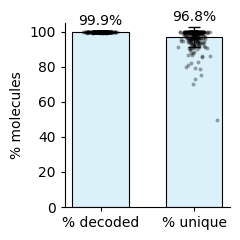

In [ ]:
plot_df = generation_summary.copy()

metrics = {
    "pct_decoded": "% decoded",
    "pct_unique_among_decoded": "% unique",
}

long_df = []

for metric, label in metrics.items():
    tmp = plot_df[["species", metric]].copy()
    tmp = tmp.rename(columns={metric: "value"})
    tmp["metric"] = label
    long_df.append(tmp)

long_df = pd.concat(long_df, ignore_index=True).dropna(subset=["value"])

metric_order = list(metrics.values())

summary_plot = (
    long_df
    .groupby("metric")["value"]
    .agg(["mean", "std", "count"])
    .reindex(metric_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(2.5, 2.5))

x = np.arange(len(summary_plot))

ax.bar(
    x,
    summary_plot["mean"],
    yerr=summary_plot["std"],
    width=0.6,
    color="#dbf1faff",
    edgecolor="black",
    linewidth=0.8,
    capsize=4,
    error_kw={
        "elinewidth": 1,
        "capthick": 1,
        "ecolor": "black",
    },
    zorder=1,
)

rng = np.random.default_rng(13)

for i, metric in enumerate(metric_order):
    vals = long_df.loc[long_df["metric"] == metric, "value"].values
    jitter = rng.normal(0, 0.06, size=len(vals))

    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        color="black",
        alpha=0.35,
        s=8,
        linewidths=0,
        zorder=2,
    )

for i, row in summary_plot.iterrows():
    ax.text(
        i,
        row["mean"] + row["std"] + 2,
        f"{row['mean']:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_xticks(x)
ax.set_xticklabels(summary_plot["metric"])
ax.set_ylabel("% molecules")
ax.set_ylim(0, 105)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=3, width=0.8)

plt.tight_layout()

plt.show()

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Per-molecule distributions
# -----------------------------
mol_metrics = {
    "closest_intraset_tanimoto": "Per mol.\nclosest gen.",
    "closest_active_tanimoto": "Per mol.\nclosest active",
}

mol_long = []

for metric, label in mol_metrics.items():
    tmp = tanimoto_results[["species", metric]].copy()
    tmp = tmp.rename(columns={metric: "value"})
    tmp["metric"] = label
    tmp["level"] = "molecule"
    mol_long.append(tmp)

mol_long = pd.concat(mol_long, ignore_index=True).dropna(subset=["value"])


# -----------------------------
# Per-species mean distributions
# -----------------------------
species_metrics = {
    "mean_closest_intraset_tanimoto": "Per sp. mean\nclosest gen.",
    "mean_closest_active_tanimoto": "Per sp. mean\nclosest active",
}

species_long = []

for metric, label in species_metrics.items():
    tmp = species_tanimoto_summary[["species", metric]].copy()
    tmp = tmp.rename(columns={metric: "value"})
    tmp["metric"] = label
    tmp["level"] = "species_mean"
    species_long.append(tmp)

species_long = pd.concat(species_long, ignore_index=True).dropna(subset=["value"])


# -----------------------------
# Combine
# -----------------------------
long_df = pd.concat([mol_long, species_long], ignore_index=True)

metric_order = [
    "Per mol.\nclosest gen.",
    "Per mol.\nclosest active",
    "Per sp. mean\nclosest gen.",
    "Per sp. mean\nclosest active",
]

long_df["metric"] = pd.Categorical(
    long_df["metric"],
    categories=metric_order,
    ordered=True,
)

means = (
    long_df
    .groupby("metric", observed=True)["value"]
    .mean()
    .reindex(metric_order)
)

<>:95: SyntaxWarning: invalid escape sequence '\m'
<>:95: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_22850/1196949988.py:95: SyntaxWarning: invalid escape sequence '\m'
  f"$\mu$={mean_value:.2f}",
/tmp/ipykernel_22850/1196949988.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_22850/1196949988.py:19: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.violinplot(
/tmp/ipykernel_22850/1196949988.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Within\ngenerated', 'To actives'])


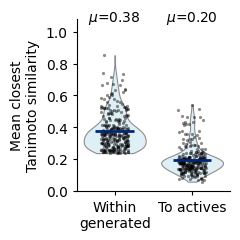

In [ ]:
metric_order = [
    "Per sp. mean\nclosest gen.",
    "Per sp. mean\nclosest active",
]
# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(2.5, 2.5))

my_colors = [
    "#dbf1faff",
    "#dbf1faff",
    "#e8e8e8",
    "#e8e8e8",
]

sns.violinplot(
    data=long_df,
    x="metric",
    y="value",
    order=metric_order,
    inner=None,
    cut=0,
    ax=ax,
    palette=my_colors,
    linewidth=0.8,
)

# -----------------------------
# Points
# -----------------------------
rng = np.random.default_rng(13)

plot_points = []

for metric in metric_order:
    vals_df = long_df[long_df["metric"] == metric].copy()

    # Subsample per-molecule points only, not species means
    if metric.startswith("Per molecule") and len(vals_df) > 5000:
        vals_df = vals_df.sample(n=5000, random_state=13)

    plot_points.append(vals_df)

plot_points = pd.concat(plot_points, ignore_index=True)


sns.stripplot(
    data=plot_points[plot_points["level"] == "species_mean"],
    x="metric",
    y="value",
    order=metric_order,
    color="black",
    alpha=0.45,
    size=2.3,
    jitter=0.18,
    ax=ax,
)

# -----------------------------
# Mean lines and labels
# -----------------------------
for i, metric in enumerate(metric_order):
    
    mean_value = means.loc[metric]

    ax.hlines(
        mean_value,
        i - 0.25,
        i + 0.25,
        colors="#022778",
        linewidth=2,
        zorder=5,
    )

    ax.text(
        i,
        1.035,
        f"$\mu$={mean_value:.2f}",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("")
ax.set_ylabel("Mean closest\nTanimoto similarity")
ax.set_ylim(0, 1.08)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=3, width=0.8)

plt.tight_layout()

ax.set_xticklabels(['Within\ngenerated', 'To actives'])
    

plt.show()

# Supplementary figure 2 d (Figure A.4.2 d)

In [ ]:
# -----------------------------
# Highest / lowest species for uniqueness-validity plot
# -----------------------------
validity_metrics = [
    "pct_decoded",
    "pct_unique_among_decoded",
    "pct_unique_among_generated",
]

validity_extremes = []

for metric in validity_metrics:
    df = generation_summary.dropna(subset=[metric]).copy()

    min_row = df.loc[df[metric].idxmin()]
    max_row = df.loc[df[metric].idxmax()]

    validity_extremes.append({
        "plot": "validity_uniqueness",
        "metric": metric,
        "extreme": "lowest",
        "species": min_row["species"],
        "value": min_row[metric],
        "n_generated": min_row.get("n_generated", np.nan),
        "n_decoded_valid": min_row.get("n_decoded_valid", np.nan),
        "n_unique_valid": min_row.get("n_unique_valid", np.nan),
    })

    validity_extremes.append({
        "plot": "validity_uniqueness",
        "metric": metric,
        "extreme": "highest",
        "species": max_row["species"],
        "value": max_row[metric],
        "n_generated": max_row.get("n_generated", np.nan),
        "n_decoded_valid": max_row.get("n_decoded_valid", np.nan),
        "n_unique_valid": max_row.get("n_unique_valid", np.nan),
    })

validity_extremes = pd.DataFrame(validity_extremes)
display(validity_extremes)

,plot,metric,extreme,species,value,n_generated,n_decoded_valid,n_unique_valid
0,validity_uniqueness,pct_decoded,lowest,chromobacteriumviolaceum,99.111111,900,892,881
1,validity_uniqueness,pct_decoded,highest,acinetobacterbaumannii,100.000000,1000,1000,1000
2,validity_uniqueness,pct_unique_among_decoded,lowest,providenciarettgeri,49.444444,900,900,445
3,validity_uniqueness,pct_unique_among_decoded,highest,acinetobacterbaumannii,100.000000,1000,1000,1000
4,validity_uniqueness,pct_unique_among_generated,lowest,providenciarettgeri,49.444444,900,900,445
5,validity_uniqueness,pct_unique_among_generated,highest,acinetobacterbaumannii,100.000000,1000,1000,1000


In [ ]:
# -----------------------------
# Highest / lowest species for closest Tanimoto plot
# -----------------------------
tanimoto_metrics = [
    "mean_closest_intraset_tanimoto",
    "mean_closest_active_tanimoto",
    "median_closest_intraset_tanimoto",
    "median_closest_active_tanimoto",
]

tanimoto_extremes = []

for metric in tanimoto_metrics:
    df = species_tanimoto_summary.dropna(subset=[metric]).copy()

    min_row = df.loc[df[metric].idxmin()]
    max_row = df.loc[df[metric].idxmax()]

    tanimoto_extremes.append({
        "plot": "closest_tanimoto",
        "metric": metric,
        "extreme": "lowest",
        "species": min_row["species"],
        "value": min_row[metric],
        "n_generated_valid": min_row.get("n_generated_valid", np.nan),
        "n_active_reference": min_row.get("n_active_reference", np.nan),
    })

    tanimoto_extremes.append({
        "plot": "closest_tanimoto",
        "metric": metric,
        "extreme": "highest",
        "species": max_row["species"],
        "value": max_row[metric],
        "n_generated_valid": max_row.get("n_generated_valid", np.nan),
        "n_active_reference": max_row.get("n_active_reference", np.nan),
    })

tanimoto_extremes = pd.DataFrame(tanimoto_extremes)
display(tanimoto_extremes)

,plot,metric,extreme,species,value,n_generated_valid,n_active_reference
0,closest_tanimoto,mean_closest_intraset_tanimoto,lowest,streptomycesgriseus,0.236783,894,11
1,closest_tanimoto,mean_closest_intraset_tanimoto,highest,providenciarettgeri,0.851463,900,382
2,closest_tanimoto,mean_closest_active_tanimoto,lowest,tsukamurellapulmonis,0.057283,899,1
3,closest_tanimoto,mean_closest_active_tanimoto,highest,providenciarettgeri,0.541642,900,382
4,closest_tanimoto,median_closest_intraset_tanimoto,lowest,lactococcuslactis,0.222222,900,13
5,closest_tanimoto,median_closest_intraset_tanimoto,highest,providenciarettgeri,1.000000,900,382
6,closest_tanimoto,median_closest_active_tanimoto,lowest,tsukamurellapulmonis,0.057471,899,1
7,closest_tanimoto,median_closest_active_tanimoto,highest,providenciarettgeri,0.585714,900,382


In [ ]:
species_tanimoto_summary[species_tanimoto_summary['species']=='streptococcuspneumoniae']

,species,n_generated_valid,n_active_reference,mean_closest_intraset_tanimoto,median_closest_intraset_tanimoto,std_closest_intraset_tanimoto,mean_closest_active_tanimoto,median_closest_active_tanimoto,std_closest_active_tanimoto
242,streptococcuspneumoniae,900,6453,0.679781,0.688345,0.245549,0.50604,0.518987,0.200548


In [ ]:
# Species with the highest mean similarity within the generated set
top_intraset = (
    species_tanimoto_summary[
        ["species", "mean_closest_intraset_tanimoto"]
    ]
    .dropna()
    .sort_values("mean_closest_intraset_tanimoto", ascending=False)
    .head(10)
)

display(top_intraset)

,species,mean_closest_intraset_tanimoto
195,providenciarettgeri,0.851463
144,morganellamorganii,0.743475
211,shigellaboydii,0.735968
196,providenciastuartii,0.714657
104,enterococcusgallinarum,0.698462
242,streptococcuspneumoniae,0.679781
176,peptococcusniger,0.669132
236,streptococcusequinus,0.666795
97,enterobactercloacae,0.664714
148,mycobacteriumkansasii,0.640634


In [ ]:
# Species with the highest mean similarity to known actives
top_active = (
    species_tanimoto_summary[
        ["species", "mean_closest_active_tanimoto"]
    ]
    .dropna()
    .sort_values("mean_closest_active_tanimoto", ascending=False)
    .head(10)
)

display(top_active)

,species,mean_closest_active_tanimoto
195,providenciarettgeri,0.541642
144,morganellamorganii,0.511718
242,streptococcuspneumoniae,0.506040
211,shigellaboydii,0.469804
23,bacilluscereus,0.462213
243,streptococcuspyogenes,0.462204
97,enterobactercloacae,0.460891
193,proteusvulgaris,0.445941
128,klebsiellapneumoniae,0.432682
71,clostridiumperfringens,0.432360


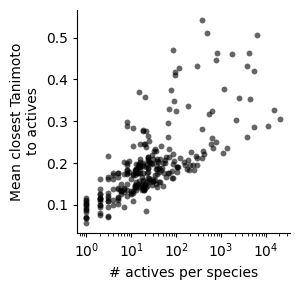

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the species-level summary produced by the script
plot_df = species_tanimoto_summary.copy()

# Keep only species with available values
plot_df = plot_df.dropna(
    subset=["mean_closest_active_tanimoto", "n_active_reference"]
).copy()

fig, ax = plt.subplots(figsize=(3.1, 3))

ax.scatter(
    plot_df["n_active_reference"],
    plot_df["mean_closest_active_tanimoto"],
    color="black",
    alpha=0.6,
    s=18,
    linewidths=0,
)

# Optional: log scale for x-axis if the number of actives varies a lot
ax.set_xscale("log")

ax.set_xlabel("# actives per species")
ax.set_ylabel("Mean closest Tanimoto\nto actives")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=3, width=0.8)

plt.tight_layout()

plt.show()

In [ ]:
from scipy.stats import spearmanr, pearsonr

In [ ]:
pearsonr(plot_df["n_active_reference"],plot_df["mean_closest_active_tanimoto"])

PearsonRResult(statistic=np.float64(0.3353418157417353), pvalue=np.float64(1.2618183655961794e-08))

In [ ]:
spearmanr(plot_df["n_active_reference"],plot_df["mean_closest_active_tanimoto"])

SignificanceResult(statistic=np.float64(0.7501153605666899), pvalue=np.float64(9.068871699482026e-51))

In [ ]:
spearmanr(plot_df["n_active_reference"],plot_df["mean_closest_intraset_tanimoto"])

SignificanceResult(statistic=np.float64(0.2715207307858334), pvalue=np.float64(5.118492027508764e-06))

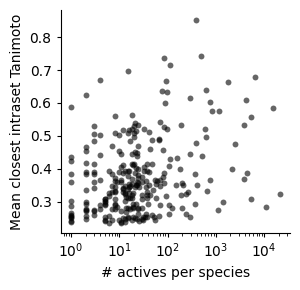

In [ ]:
# Use the species-level summary produced by the script
plot_df = species_tanimoto_summary.copy()

# Keep only species with available values
plot_df = plot_df.dropna(
    subset=["mean_closest_intraset_tanimoto", "n_active_reference"]
).copy()

fig, ax = plt.subplots(figsize=(3.1, 3))

ax.scatter(
    plot_df["n_active_reference"],
    plot_df["mean_closest_intraset_tanimoto"],
    color="black",
    alpha=0.6,
    s=18,
    linewidths=0,
)

# Optional: log scale for x-axis if the number of actives varies a lot
ax.set_xscale("log")

ax.set_xlabel("# actives per species")
ax.set_ylabel("Mean closest intraset Tanimoto")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=3, width=0.8)

plt.tight_layout()


# Figure 3 f (Figure 3.4.3 f)

In [ ]:
# Cytotoxicity, Precision @ 10, AB.likeness, QED, Solubility, MW
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from matplotlib import ticker
from src.utils import standardize_smiles


# -----------------------------
# Paths
# -----------------------------
FIG3_DIR = Path("../../data/figures_source_data/")

GEN_DIR = Path(
    "../../data/generated_molecules/extra900/"
)

CYTO_FILE = Path("../../data/figures_source_data/"
    "generated_molecules_with_cytotoxicity_solubility_and_ablikeness_predictions.csv")


# -----------------------------
# Choose 6 species
# Edit this list if needed
# -----------------------------
species_list = [
    "acinetobacterbaumannii",
    "escherichiacoli",
    "enterococcusfaecalis",
    "klebsiellapneumoniae",
    "pseudomonasaeruginosa",
    "staphylococcusaureus",
]

species_labels = {
    "acinetobacterbaumannii": "A. baumannii",
    "escherichiacoli": "E. coli",
    "enterococcusfaecalis": "E. faecalis",
    "klebsiellapneumoniae": "K. pneumoniae",
    "pseudomonasaeruginosa": "P. aeruginosa",
    "staphylococcusaureus": "S. aureus",
    "mycobacteroidesabscessus": "M. abscessus",
}


# -----------------------------
# Columns
# -----------------------------
continuous_cols = [
    "cytotoxicity_hepg2",
    "cytotoxicity_hskmc",
    "cytotoxicity_imr90",
    "precision_at_10",
    "QED",
    "solubility",
    "MW",
]

col2title = {
    "cytotoxicity_hepg2": "Cytotoxicity HepG2",
    "cytotoxicity_hskmc": "Cytotoxicity HSKMC",
    "cytotoxicity_imr90": "Cytotoxicity IMR90",
    "precision_at_10": "Precision at 10",
    "QED": "QED",
    "consensus_score": "Activity prediction",
    "solubility": "Solubility",
    "MW": "Molecular weight",
}

col2ylabel = {
    "cytotoxicity_hepg2": "Score\n(lower better)",
    "cytotoxicity_hskmc": "Score\n(lower better)",
    "cytotoxicity_imr90": "Score\n(lower better)",
    "precision_at_10": "Precision at 10\n(higher better)",
    "QED": "QED\n(higher better)",
    "consensus_score": "Score\n(higher better)",
    "solubility": "Score\n(higher better)",
    "MW": "MW",
}

indicator_cols = [
    "has_pains",
    "is_sim_known_ab",
    "nitrofuran_motif",
    "fluoroquinolone_motif",
    "carbepenem_motif",
    "betalactam_motif",
    "has_any_ablike",
]

indicator_labels = {
    "has_pains": "PAINS",
    "has_brenk": "BRENK",
    "is_sim_known_ab": "Similar known AB",
    "nitrofuran_motif": "Nitrofuran",
    "fluoroquinolone_motif": "Fluoroquinolone",
    "carbepenem_motif": "Carbapenem",
    "betalactam_motif": "β-lactam",
    "has_any": "Any alert",
    "has_any_ablike": "Any AB-like",
}


# -----------------------------
# Load cytotoxicity / solubility / antibiotic-likeness predictions
# -----------------------------
df_cyto = pd.read_csv(CYTO_FILE)

if "smiles_std" not in df_cyto.columns:
    df_cyto["smiles_std"] = df_cyto["smiles"]#.apply(standardize_smiles)

if "MW" not in df_cyto.columns:
    df_cyto["MW"] = [
        Descriptors.MolWt(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) is not None else np.nan
        for s in df_cyto["smiles"]
    ]

if "QED" not in df_cyto.columns:
    df_cyto["QED"] = [
        QED.qed(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) is not None else np.nan
        for s in df_cyto["smiles"]
    ]

df_cyto = df_cyto.dropna(subset=["smiles_std"]).copy()


# -----------------------------
# Load generated molecule evaluation files
# No filtering applied
# -----------------------------
all_species_df = []

for sp in species_list:
    metrics_file = (
        GEN_DIR
        / sp
        / "eval_joining_all_gen_mols_latent_all_library.csv"
    )

    if not metrics_file.exists():
        print(f"Missing metrics file: {metrics_file}")
        continue

    df_metrics = pd.read_csv(metrics_file)

    if "smiles_std" not in df_metrics.columns:
        df_metrics["smiles_std"] = df_metrics["smiles"].apply(standardize_smiles)

    df_metrics = df_metrics.dropna(subset=["smiles_std"]).copy()

    df_cyto_sp = df_cyto[df_cyto["species"] == sp].copy()

    keep_cyto_cols = (
        ["smiles_std"]
        + [c for c in continuous_cols if c in df_cyto_sp.columns]
        + [c for c in indicator_cols if c in df_cyto_sp.columns]
    )

    df = df_metrics.merge(
        df_cyto_sp[keep_cyto_cols].drop_duplicates("smiles_std"),
        on="smiles_std",
        how="left",
    )

    df["species"] = sp
    df["species_label"] = species_labels.get(sp, sp)

    all_species_df.append(df)

all_species_df = pd.concat(all_species_df, ignore_index=True)

# Optional but recommended: one row per generated unique molecule per species
all_species_df = all_species_df.drop_duplicates(["species", "smiles_std"]).reset_index(drop=True)

print(all_species_df.shape)
display(all_species_df.head())
display(all_species_df["species_label"].value_counts())

(5878, 34)


,smiles,ranking_first_active,auroc,random_exp_rank,closest_distance_to_active,closest_distance_to_inactive,precision_at_5,EF_at_5,precision_at_10,EF_at_10,...,MW,has_pains,is_sim_known_ab,nitrofuran_motif,fluoroquinolone_motif,carbepenem_motif,betalactam_motif,has_any_ablike,species,species_label
0,CN(C)C(=O)C1CC(O)C2OC(C[N+](=O)[O-])COC2C1C(=C...,90,0.716069,192.219721,0.348543,0.271923,0.0,0.0,0.0,0.000000,...,625.682,0,0,0,0,0,0,False,acinetobacterbaumannii,A. baumannii
1,CN=C(O)C12CCCC(=O)C1(C(=O)O)C(=O)N2C(CSC(C)(C)...,15,0.691677,192.219721,0.328575,0.269401,0.0,0.0,0.0,0.000000,...,582.676,0,0,0,0,0,1,True,acinetobacterbaumannii,A. baumannii
2,CN=C(O)C1C(=O)N(C(C=C2C(=O)N(C3=NCC(C(=O)O)S3)...,41,0.672015,192.219721,0.277165,0.226573,0.0,0.0,0.0,0.000000,...,731.563,0,0,0,0,0,1,True,acinetobacterbaumannii,A. baumannii
3,CC(=NOC(=O)C1C(C(C)O)C(=O)N1S(=O)(=O)c1cccc([N...,10,0.723227,192.219721,0.279188,0.253823,0.0,0.0,0.1,19.242489,...,702.564,0,0,0,0,0,1,True,acinetobacterbaumannii,A. baumannii
4,CC(C)OC(=O)C1C2Sc3c(nc(=N)[nH]c3CNCc3ncc([N+](...,27,0.712426,192.219721,0.230314,0.195244,0.0,0.0,0.0,0.000000,...,581.637,0,0,0,0,0,0,False,acinetobacterbaumannii,A. baumannii


species_label
A. baumannii     1000
E. coli           999
P. aeruginosa     998
S. aureus         982
E. faecalis       960
K. pneumoniae     939
Name: count, dtype: int64

In [ ]:
all_species_df.groupby('species')['precision_at_10'].mean()

species
acinetobacterbaumannii    0.052300
enterococcusfaecalis      0.771458
escherichiacoli           0.748148
klebsiellapneumoniae      0.792013
pseudomonasaeruginosa     0.657415
staphylococcusaureus      0.203870
Name: precision_at_10, dtype: float64

## Predictions using species-specific models

In [ ]:
# Predictions
import logging
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm.auto import tqdm
from src.utils import load_compound_encoder, encode_mols

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

MODELS_ROOT = (
    "../../models/activity_predictors"
)

MODEL_TYPES = [
    "RandomForest",
    "XGBoost",
    "LogisticRegression",
    "MLP",
]

FEATURE_TYPES = ["Latent", "ECFP4"]

N_FOLDS = 5

dotP_encoder = load_compound_encoder()

# ---------------------------------------------------------------------
# Feature generation
# ---------------------------------------------------------------------

def get_ecfp4(smiles: str, n_bits: int = 2048) -> np.ndarray | None:
    """
    Generate an ECFP4 fingerprint.

    Returns None when the SMILES cannot be parsed.
    """
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles))

    if mol is None:
        return None

    fingerprint = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=n_bits,
    )

    return np.asarray(fingerprint, dtype=np.float32)


# ---------------------------------------------------------------------
# Species-name handling
# ---------------------------------------------------------------------

def species_to_model_name(species: str) -> str:
    """
    Convert a species name into the format used in the model directories.

    Examples
    --------
    'Escherichia coli' -> 'escherichiacoli'
    'M. tuberculosis'  -> 'mtuberculosis'

    Modify this function if your model-directory names follow another rule.
    """
    species = str(species).strip().lower()
    return re.sub(r"[^a-z0-9]", "", species)


# If dataframe species names do not map automatically to the directory
# names, define explicit replacements here.
SPECIES_NAME_MAP = {
    # "Escherichia coli": "escherichiacoli",
    # "Pseudomonas aeruginosa": "pseudomonasaeruginosa",
    # "Mycobacteroides abscessus": "mycobacteroidesabscessus",
}


def get_model_species_name(species: str) -> str:
    return SPECIES_NAME_MAP.get(species, species_to_model_name(species))


# ---------------------------------------------------------------------
# Load encoder once
# ---------------------------------------------------------------------

logging.info("Loading compound encoder...")

dotP_encoder.eval()


# ---------------------------------------------------------------------
# Generate features once for every unique SMILES
# ---------------------------------------------------------------------

unique_smiles = all_species_df["smiles"].dropna().astype(str).unique()

logging.info(
    "Generating ECFP4 fingerprints for %d unique SMILES...",
    len(unique_smiles),
)

fingerprint_lookup = {}

for smiles in tqdm(unique_smiles, desc="Calculating ECFP4"):
    fingerprint_lookup[smiles] = get_ecfp4(smiles)


# Mark which rows have valid molecular structures.
all_species_df["valid_smiles"] = (
    all_species_df["smiles"]
    .astype(str)
    .map(lambda x: fingerprint_lookup.get(x) is not None)
)

# Initialize the output column.
all_species_df["consensus_score"] = np.nan


# ---------------------------------------------------------------------
# Predict separately for each species
# ---------------------------------------------------------------------

for species, species_df in all_species_df.groupby("species", sort=False):

    model_species = get_model_species_name(species)

    if model_species == "mycobacteroidesabscessus":
        logging.info(
            "Skipping %s because no prediction models are available.",
            species,
        )
        continue

    base_model_path = os.path.join(MODELS_ROOT, model_species)

    if not os.path.isdir(base_model_path):
        logging.warning(
            "No model directory found for species '%s': %s",
            species,
            base_model_path,
        )
        continue

    # Keep only rows with valid SMILES for this species.
    valid_indices = species_df.index[
        species_df["valid_smiles"]
    ]

    if len(valid_indices) == 0:
        logging.warning(
            "No valid SMILES found for species '%s'.",
            species,
        )
        continue

    species_smiles = (
        all_species_df.loc[valid_indices, "smiles"]
        .astype(str)
        .tolist()
    )

    X_ecfp4 = np.vstack([
        fingerprint_lookup[smiles]
        for smiles in species_smiles
    ]).astype(np.float32)

    X_latent = [encode_mols(x, model=dotP_encoder) for x in X_ecfp4]
    X_latent = np.vstack(X_latent).astype(np.float32)
        
    # Each entry will contain the fold-averaged predictions from one
    # model/feature combination.
    ensemble_predictions = []

    for model_name in MODEL_TYPES:
        for feature_type in FEATURE_TYPES:

            model_dir = os.path.join(
                base_model_path,
                f"{model_name}_{feature_type}",
            )

            if not os.path.isdir(model_dir):
                logging.warning(
                    "Model directory not found: %s",
                    model_dir,
                )
                continue

            current_X = (
                X_latent
                if feature_type == "Latent"
                else X_ecfp4
            )

            fold_predictions = []

            for fold in range(N_FOLDS):

                model_path = os.path.join(
                    model_dir,
                    f"fold_{fold}.joblib",
                )

                if not os.path.isfile(model_path):
                    logging.warning(
                        "Missing model: %s",
                        model_path,
                    )
                    continue

                classifier = joblib.load(model_path)

                if not hasattr(classifier, "predict_proba"):
                    raise AttributeError(
                        f"{model_path} does not implement predict_proba()."
                    )

                probabilities = classifier.predict_proba(current_X)

                # Identify the column corresponding to the active class.
                class_labels = np.asarray(classifier.classes_)
                active_positions = np.where(class_labels == 1)[0]

                if len(active_positions) != 1:
                    raise ValueError(
                        f"Could not identify active class 1 in "
                        f"{model_path}. Classes: {class_labels}"
                    )

                active_class_position = active_positions[0]
                fold_predictions.append(
                    probabilities[:, active_class_position]
                )

            if fold_predictions:
                # Average the five folds for this model/feature pair.
                model_feature_score = np.mean(
                    np.vstack(fold_predictions),
                    axis=0,
                )

                ensemble_predictions.append(model_feature_score)

                logging.info(
                    "%s: completed %s_%s using %d folds.",
                    species,
                    model_name,
                    feature_type,
                    len(fold_predictions),
                )

    if not ensemble_predictions:
        logging.warning(
            "No successful model predictions for species '%s'.",
            species,
        )
        continue

    # Consensus = average of the fold-averaged predictions from all
    # available model/feature combinations.
    consensus_score = np.mean(
        np.vstack(ensemble_predictions),
        axis=0,
    )

    all_species_df.loc[
        valid_indices,
        "consensus_score",
    ] = consensus_score

    logging.info(
        "Added predictions for %d molecules against %s "
        "using %d model/feature combinations.",
        len(valid_indices),
        species,
        len(ensemble_predictions),
    )


logging.info(
    "Prediction complete. Scores generated for %d of %d rows.",
    all_species_df["consensus_score"].notna().sum(),
    len(all_species_df),
)


/aloy/home/grojas/anaconda3/envs/ersilia/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-26 09:48:47,151 - INFO - Loading compound encoder...
2026-06-26 09:48:52,609 - INFO - Generating ECFP4 fingerprints for 5861 unique SMILES...
Calculating ECFP4: 100%|██████████| 5861/5861 [00:07<00:00, 826.88it/s]
/aloy/home/grojas/anaconda3/envs/ersilia/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/aloy/home/grojas/anaconda3/envs/ersilia/lib/python3.12/site-packages/sk

In [ ]:
all_species_df.valid_smiles.value_counts()

valid_smiles
True    5878
Name: count, dtype: int64

In [ ]:
# -----------------------------
# Build long dataframe for continuous metrics
# -----------------------------
plot_long = []
continuous_cols += ["consensus_score"]
for col in continuous_cols:
    if col not in all_species_df.columns:
        print(f"Skipping missing column: {col}")
        continue

    tmp = all_species_df[["species", "species_label", "smiles_std", col]].copy()
    tmp = tmp.rename(columns={col: "value"})
    tmp["metric"] = col
    tmp = tmp.dropna(subset=["value"])

    plot_long.append(tmp)

plot_long = pd.concat(plot_long, ignore_index=True)

species_order = [species_labels[sp] for sp in species_list if species_labels[sp] in all_species_df["species_label"].unique()]

palette_species = {
    sp_label: "#dbf1faff"
    for sp_label in species_order
}

In [ ]:
plot_long

,species,species_label,smiles_std,value,metric
0,acinetobacterbaumannii,A. baumannii,CN(C)C(=O)C1CC(O)C2OC(C[N+](=O)[O-])COC2C1C(=C...,0.053212,cytotoxicity_hepg2
1,acinetobacterbaumannii,A. baumannii,CNC(=O)C12CCCC(=O)C1(C(=O)O)C(=O)N2C(CSC(C)(C)...,0.045734,cytotoxicity_hepg2
2,acinetobacterbaumannii,A. baumannii,CNC(=O)C1C(=O)N(C(C=C2C(=O)N(C3=NCC(C(=O)O)S3)...,0.073517,cytotoxicity_hepg2
3,acinetobacterbaumannii,A. baumannii,CC(=NOC(=O)C1C(C(C)O)C(=O)N1S(=O)(=O)c1cccc([N...,0.059456,cytotoxicity_hepg2
4,acinetobacterbaumannii,A. baumannii,CC(C)OC(=O)C1C2Sc3c(CNCc4ncc([N+](=O)[O-])n4C)...,0.221487,cytotoxicity_hepg2
...,...,...,...,...,...
47019,staphylococcusaureus,S. aureus,CCCCCCCOc1cc(C)cc(Nc2ccnc(Cc3ccc4ccccc4c3)n2)n1,0.301602,consensus_score
47020,staphylococcusaureus,S. aureus,CCc1cc(SCN(Cc2cccc(OCOC)c2)c2ccc(Cl)cc2)c2cc(-...,0.261051,consensus_score
47021,staphylococcusaureus,S. aureus,Cc1cc(C(=O)NCc2ccnc(C)c2Cl)ccc1CC(c1cc(C)c2c(c...,0.182453,consensus_score
47022,staphylococcusaureus,S. aureus,CC1(C)C=CC=C(Cc2cc(C(=O)CCO)ccc2N)C1,0.210379,consensus_score


In [ ]:
# -----------------------------
# Combine cytotoxicity into one metric
# max across the 3 models (higher = worse, lower = better)
# -----------------------------
cyto_cols = ["cytotoxicity_hepg2", "cytotoxicity_hskmc", "cytotoxicity_imr90"]
df_pred = all_species_df.copy()

missing_cyto = [c for c in cyto_cols if c not in df_pred.columns]
if len(missing_cyto) > 0:
    raise ValueError(f"Missing cytotoxicity columns: {missing_cyto}")

df_pred["cytotoxicity_max"] = df_pred[cyto_cols].max(axis=1)

In [ ]:
# -----------------------------
# Metrics for the 2x3 grid
# -----------------------------
metric_order = [
    "precision_at_10",
    "consensus_score",
    "cytotoxicity_max",
    "solubility",
    "MW",
]

metric_titles = {
    "cytotoxicity_max": "Cytotoxicity",
    "precision_at_10": "Precision at 10",
    "QED": "QED",
    "consensus_score": "Activity prediction",
    "solubility": "Solubility",
    "MW": "Molecular weight",
}

metric_ylabels = {
    "cytotoxicity_max": "Score\n(lower better)",
    "precision_at_10": "Precision at 10\n(higher better)",
    "QED": "QED\n(higher better)",
    "consensus_score": "Score\n(higher better)",
    "solubility": "Predicted LogS\n(higher better)",
    "MW": "MW",
}

species_order = [species_labels[s] for s in species_list]


## Add precision at 10 baseline per species

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path(
    "../../data/figures_source_data/chembl_compound_species_activity_datapoints.csv"
)

MABS_PATH = Path(
    "../../data/figures_source_data/mycobacteroidesabscessus_chembl_data.csv"
)

all_data = pd.read_csv(DATA_PATH)

# One row per unique molecule in the global dataset
global_library = all_data.drop_duplicates("smiles").copy()
n_total_library = len(global_library)

# Active molecules per species in the main dataset
active_main = (
    all_data
    .loc[all_data["active"] == 1, ["species", "smiles"]]
    .dropna()
    .drop_duplicates(["species", "smiles"])
)

baseline_main = (
    active_main
    .groupby("species")["smiles"]
    .nunique()
    .reset_index(name="n_active")
)

baseline_main["n_total_library"] = n_total_library
baseline_main["random_precision_at_10"] = (
    baseline_main["n_active"] / baseline_main["n_total_library"]
)

# M. abscessus special case
mabs_data = pd.read_csv(MABS_PATH)

mabs_active = (
    mabs_data
    .loc[mabs_data["active"] == 1, ["smiles"]]
    .dropna()
    .drop_duplicates("smiles")
)

baseline_mabs = pd.DataFrame({
    "species": ["mycobacteroidesabscessus"],
    "n_active": [mabs_active["smiles"].nunique()],
    "n_total_library": [n_total_library],
})

baseline_mabs["random_precision_at_10"] = (
    baseline_mabs["n_active"] / baseline_mabs["n_total_library"]
)

# Combine, replacing M. abscessus if present
baseline_df = baseline_main[
    baseline_main["species"] != "mycobacteroidesabscessus"
].copy()

baseline_df = pd.concat(
    [baseline_df, baseline_mabs],
    ignore_index=True,
)

baseline_df["random_precision_at_10_percent"] = (
    100 * baseline_df["random_precision_at_10"]
)

baseline_df.head()

,species,n_active,n_total_library,random_precision_at_10,random_precision_at_10_percent
0,acinetobacterbaumannii,1121,186462,0.006012,0.601195
1,acinetobacterbaylyi,2,186462,0.000011,0.001073
2,acinetobactercalcoaceticus,149,186462,0.000799,0.079909
3,acinetobactercalcoaceticussubsp.anitratus,3,186462,0.000016,0.001609
4,acinetobacterhaemolyticus,8,186462,0.000043,0.004290


In [ ]:
baseline_df = baseline_df[baseline_df["species"].isin(species_list)].copy()
baseline_df["species_label"] = baseline_df["species"].map(species_labels)

baseline_df = (
    baseline_df
    .set_index("species_label")
    .loc[species_order]
    .reset_index()
)

display(baseline_df)

,species_label,species,n_active,n_total_library,random_precision_at_10,random_precision_at_10_percent
0,A. baumannii,acinetobacterbaumannii,1121,186462,0.006012,0.601195
1,E. coli,escherichiacoli,11223,186462,0.060189,6.018921
2,E. faecalis,enterococcusfaecalis,5314,186462,0.028499,2.849910
3,K. pneumoniae,klebsiellapneumoniae,3878,186462,0.020798,2.079780
4,P. aeruginosa,pseudomonasaeruginosa,5455,186462,0.029255,2.925529
5,S. aureus,staphylococcusaureus,21013,186462,0.112693,11.269320


## Add out of fold score distributions to the predictions plot

In [ ]:
## Add out of fold scores distributions
from pathlib import Path
import pandas as pd

# Metrics computed using /src/ChEMBL_prediction_models/selected_species/get_cv_metrics_for_species_specific_models.py

MODELS_ROOT = Path(
    "../../data/figures_source_data/out_of_fold_prediction_scores_activity_predictors"
)

# Directory names used by the prediction models
species_model_names = {
    "A. baumannii": "acinetobacterbaumannii",
    "E. faecalis": "enterococcusfaecalis",
    "E. coli": "escherichiacoli",
    "K. pneumoniae": "klebsiellapneumoniae",
    "P. aeruginosa": "pseudomonasaeruginosa",
    "S. aureus": "staphylococcusaureus",
}

oof_tables = []

for species_label, model_species in species_model_names.items():
    path = (
        MODELS_ROOT
        / model_species
        / "out_of_fold_consensus_scores.csv"
    )

    if not path.exists():
        raise FileNotFoundError(f"Missing OOF scores: {path}")

    tmp = pd.read_csv(path)
    tmp["species_label"] = species_label
    oof_tables.append(tmp)

oof_df = pd.concat(oof_tables, ignore_index=True)

# Median OOF consensus score for each class and species
oof_medians = (
    oof_df
    .groupby(["species_label", "active"])["consensus_score"]
    .median()
    .unstack("active")
    .rename(columns={
        0: "inactive_median",
        1: "active_median",
    })
    .reindex(species_order)
)

print(oof_medians)

active         inactive_median  active_median
species_label                                
A. baumannii          0.001481       0.614776
E. coli               0.067103       0.676207
E. faecalis           0.098722       0.781150
K. pneumoniae         0.019888       0.814504
P. aeruginosa         0.014527       0.659383
S. aureus             0.108873       0.744896


In [ ]:
oof_summary = (
    oof_df
    .groupby(["species_label", "active"])["consensus_score"]
    .agg(
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

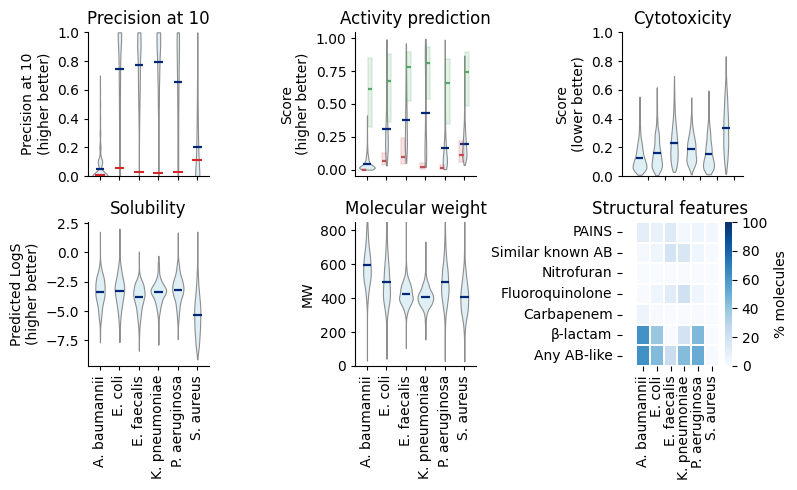

In [ ]:
# -----------------------------
# 2 x 3 figure
# share x axis by column
# -----------------------------
from matplotlib.patches import Rectangle
fig, axes = plt.subplots(
    2, 3,
    figsize=(8, 5),
    sharex="col",
    # gridspec_kw={"wspace": 0.35, "hspace": 0.38}
)
axes = axes.flatten()

# Continuous panels: first 5 slots
for i, metric in enumerate(metric_order):
    ax = axes[i]

    df_plot = plot_long[plot_long["metric"] == metric].copy()

    sns.violinplot(
        data=df_plot,
        x="species_label",
        y="value",
        order=species_order,
        inner=None,
        cut=0,
        color="#dbf1faff",
        linewidth=0.8,
        ax=ax,
    )

    # Subsample points only for visibility
    point_df = []
    for sp_label in species_order:
        sp_df = df_plot[df_plot["species_label"] == sp_label].copy()
        if len(sp_df) > 250:
            sp_df = sp_df.sample(n=250, random_state=13)
        point_df.append(sp_df)

    point_df = pd.concat(point_df, ignore_index=True)

    ax.set_xlim(-0.6, len(species_order) - 0.4)
    
    # Median line per species
    means = df_plot.groupby("species_label")["value"].mean()

    for j, sp_label in enumerate(species_order):
        if sp_label not in means.index:
            continue

        ax.hlines(
            means.loc[sp_label],
            j - 0.22,
            j + 0.22,
            colors="#022778",
            linewidth=1.6,
            zorder=5,
        )

    if metric == "precision_at_10":
        baseline_map = baseline_df.set_index("species_label")["random_precision_at_10"].to_dict()

        for j, sp_label in enumerate(species_order):
            if sp_label not in baseline_map:
                print('ok')
            else:
                ax.hlines(
                    baseline_map[sp_label],
                    j - 0.25,
                    j + 0.25,
                    colors="tab:red",
                    linestyles="-",
                    linewidth=1.5,
                    zorder=6,
                )
        # OOF reference scores for the activity-prediction panel
    if metric == "consensus_score":

        class_styles = {
            0: {
                "label": "Known inactive",
                "color": "#C44E52",
                "offset": -0.14,
            },
            1: {
                "label": "Known active",
                "color": "#55A868",
                "offset": 0.14,
            },
        }

        box_width = 0.22

        for j, sp_label in enumerate(species_order):

            species_summary = oof_summary[
                oof_summary["species_label"] == sp_label
            ]

            for active_class, style in class_styles.items():

                row = species_summary[
                    species_summary["active"] == active_class
                ]

                if row.empty:
                    continue

                q25 = row["q25"].iloc[0]
                median = row["median"].iloc[0]
                q75 = row["q75"].iloc[0]

                x_center = j + style["offset"]
                x_left = x_center - box_width / 2

                # Interquartile range: 25th to 75th percentile
                rectangle = Rectangle(
                    (x_left, q25),
                    box_width,
                    q75 - q25,
                    facecolor=style["color"],
                    edgecolor=style["color"],
                    alpha=0.15,
                    linewidth=1.3,
                    zorder=6,
                )

                ax.add_patch(rectangle)

                # Median line
                ax.hlines(
                    median,
                    x_left,
                    x_left + box_width,
                    colors=style["color"],
                    linestyles="-",
                    linewidth=1.6,
                    zorder=7,
                )
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel(metric_ylabels[metric])

    ax.tick_params(axis="x", rotation=90)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=3, width=0.8)

    if metric in ["cytotoxicity_max", "precision_at_10", "QED"]:
        ax.set_ylim(0, 1)

    if metric == "MW":
        ax.set_ylim(0, 850)
    if metric == 'QED':
        ax.set_xlim(-2, 7)

# -----------------------------
# Sixth panel: AB-like features heatmap
# species on x axis, features on y axis
# -----------------------------
ax = axes[5]

available_indicator_cols = [c for c in indicator_cols if c in df_pred.columns]

heatmap_df = (
    df_pred
    .groupby("species_label")[available_indicator_cols]
    .mean()
    .reindex(species_order)
    .T
    * 100
)

heatmap_df.index = [indicator_labels.get(i, i) for i in heatmap_df.index]

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% molecules"},
    linewidths=0.3,
    linecolor="white",
)
ax.set_xlim(-1, len(species_order))
ax.set_title("Structural features")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()